In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Descarga de datos

tickers = {
    "EURUSD": "EURUSD=X",
    "GBPUSD": "GBPUSD=X",
    "BTC": "BTC-USD",
    "ETH": "ETH-USD"
}

data = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start="2018-01-01", progress=False)
    df = df[["Close"]].rename(columns={"Close": name})
    data[name] = df
    print(f"{name}: {len(df)} registros descargados")

EURUSD: 2119 registros descargados
GBPUSD: 2119 registros descargados
BTC: 2974 registros descargados
ETH: 2974 registros descargados


Vemos diferencias de registros, pero eso viene porque el mercado tradicional opera de lunes a viernes, en cambio,  el mercado de las criptomonedas cotizan los 365 días del año.

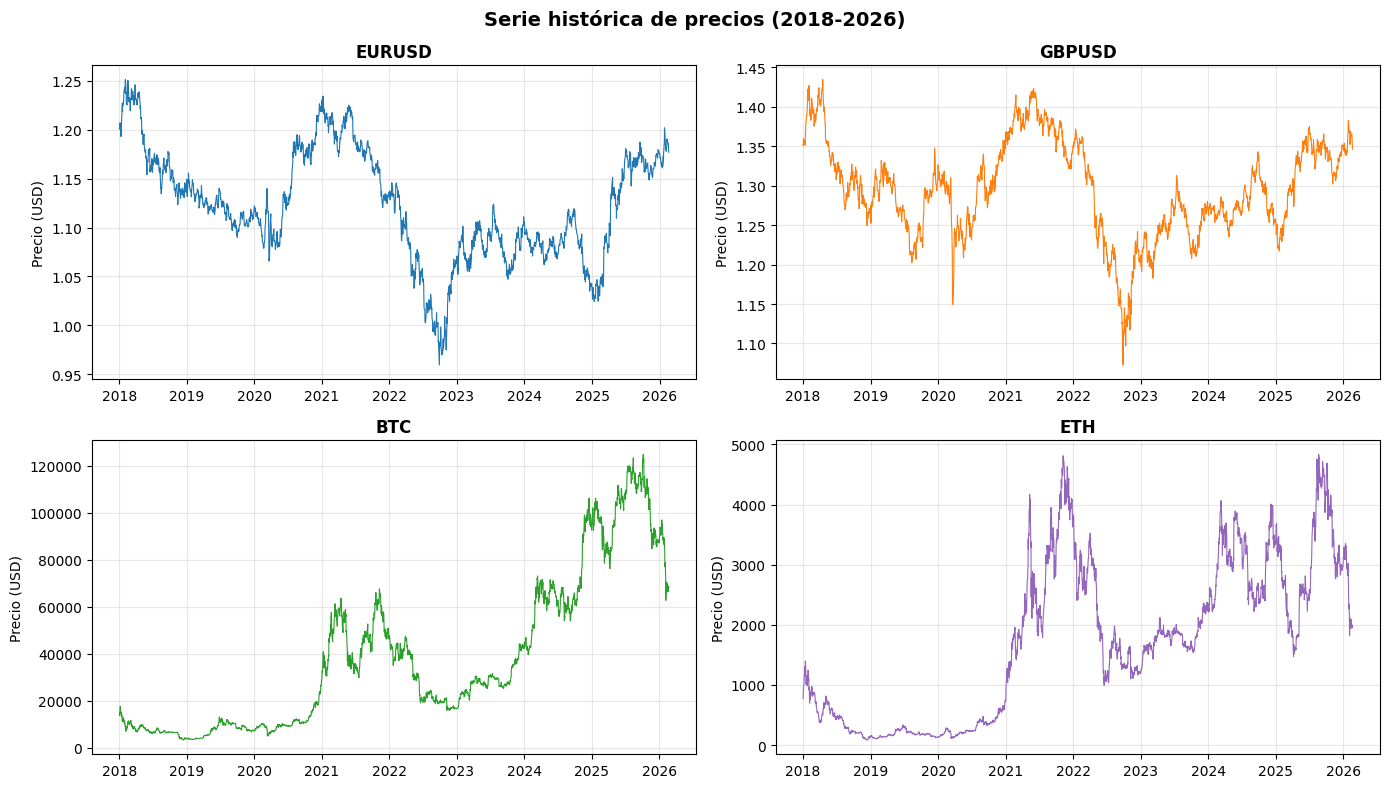

Gráfico guardado en results/


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Serie histórica de precios (2018-2026)", fontsize=14, fontweight="bold")

colores = {"EURUSD": "#1f77b4", "GBPUSD": "#ff7f0e", "BTC": "#2ca02c", "ETH": "#9467bd"}

for ax, (name,df) in zip (axes.flatten(), data.items()):
    ax.plot(df.index, df[name], color=colores[name], linewidth=0.8)
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Precio (USD)")
    ax.grid (True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/01_series_historicas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en results/")

- A simple vista podemos observar que las divisas EUR/USD oscila entre 0.95 y 1.25, el GBP/USD entre 1.10 y 1.45. No tienen tendencia a largo plazo y tampoco tienen una amplitud ancha.

- En cambio las criptomonedas, BTC pasó de 0 a 120.000$ con caidas de 70-80%. ETH tiene un patrón muy parecido al Bitcoin.

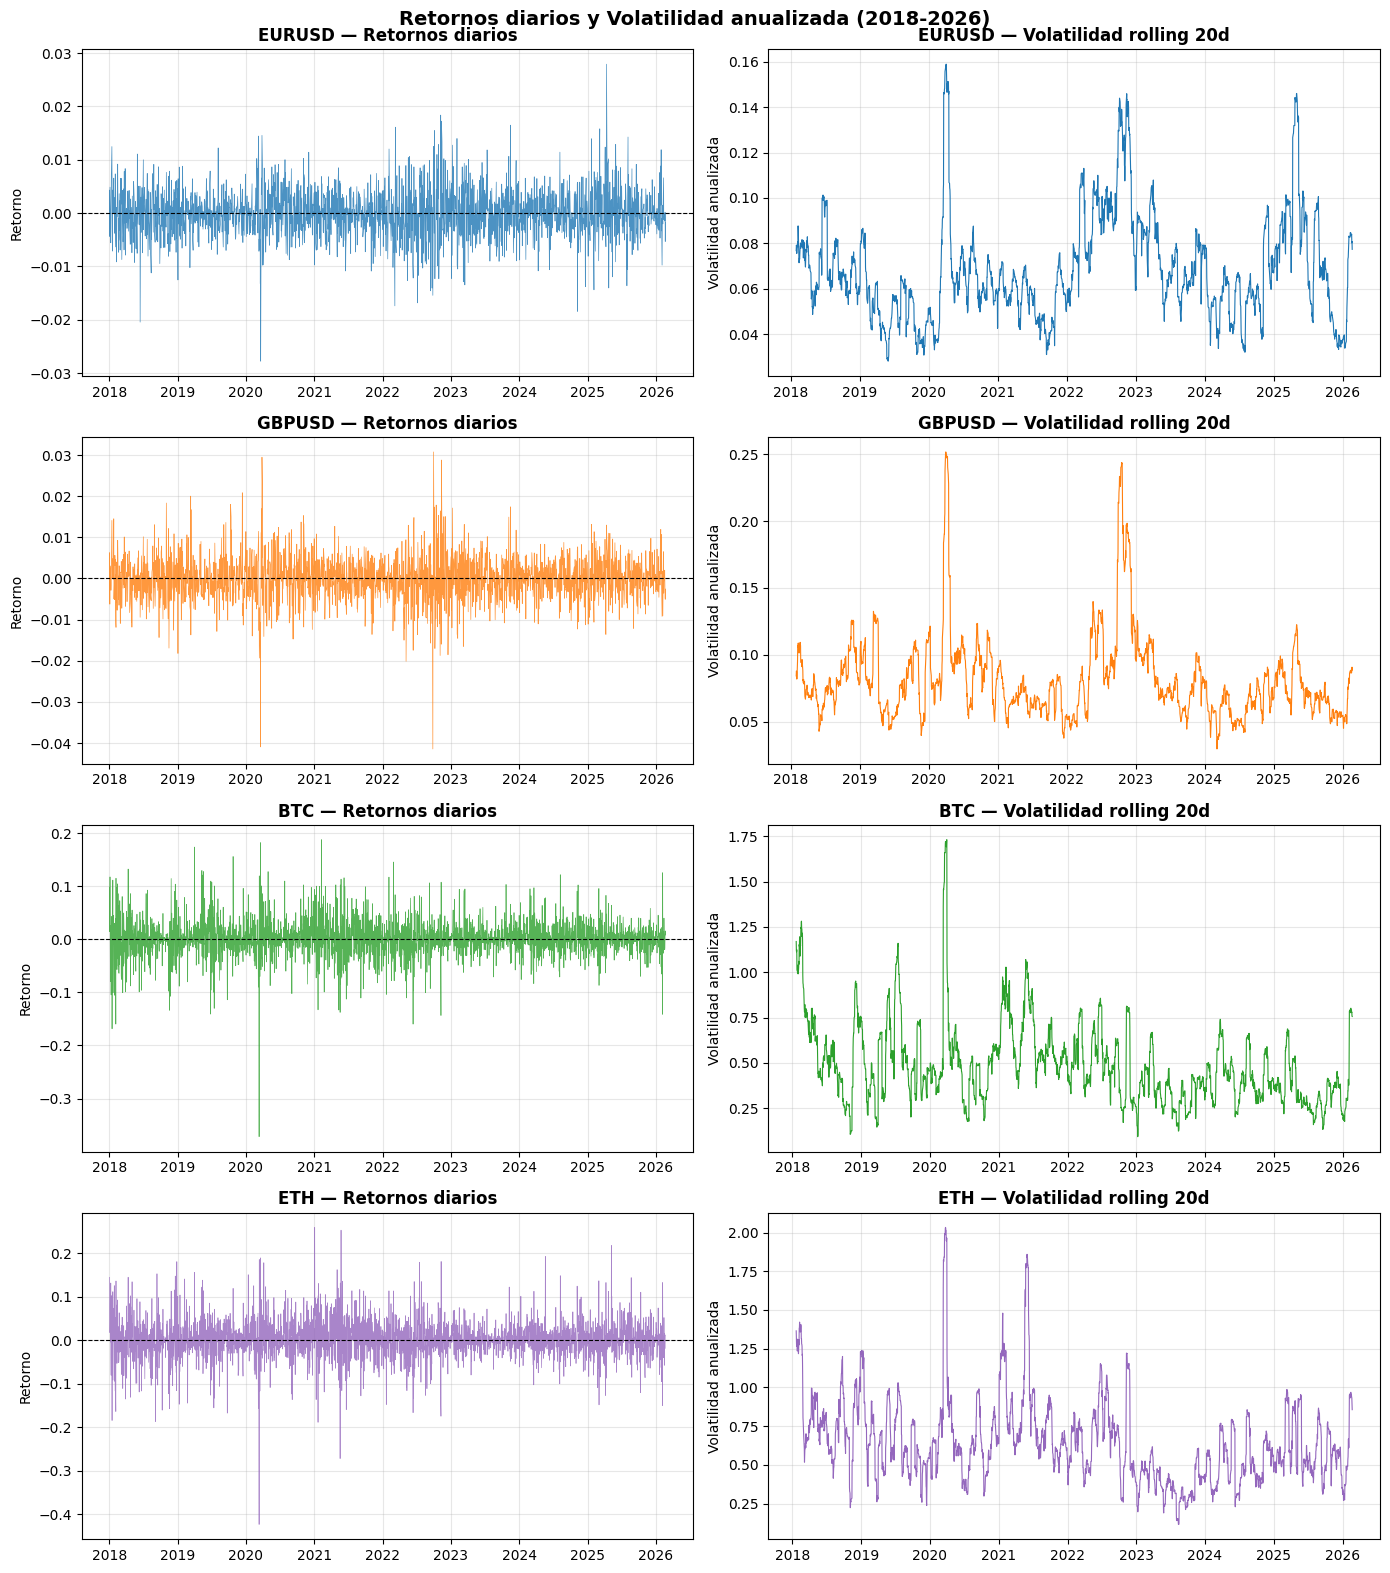

Gráfico guardado en results/


In [7]:
# Calcular retornos logarítmicos y volatilidad rolling
retornos = {}
volatilidad = {}

for name, df in data.items():
    # Retornos logarítmicos diarios
    ret = df[name].pct_change().dropna()
    retornos[name] = ret
    
    # Volatilidad rolling de 20 días (media móvil de la desviación estándar)
    vol = ret.rolling(window=20).std() * (252 ** 0.5) # Anualizada
    volatilidad[name] = vol
    
# Visualizar retornos y volatilidad
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle("Retornos diarios y Volatilidad anualizada (2018-2026)", fontsize=14, fontweight="bold")

for i, name in enumerate(data.keys()):
    color = colores[name]
    
    # Retornos
    axes[i, 0].plot(retornos[name].index, retornos[name], color=color, linewidth=0.5, alpha=0.8)
    axes[i, 0].set_title(f"{name} — Retornos diarios", fontweight="bold")
    axes[i, 0].set_ylabel("Retorno")
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].axhline(0, color="black", linewidth=0.8, linestyle="--")
    
    # Volatilidad
    axes[i, 1].plot(volatilidad[name].index, volatilidad[name], color=color, linewidth=0.8)
    axes[i, 1].set_title(f"{name} — Volatilidad rolling 20d", fontweight="bold")
    axes[i, 1].set_ylabel("Volatilidad anualizada")
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/02_retornos_volatilidad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en results/")

* En divisas EUR/USD y GBP/USD: Los retornos se mueven en un del 3% y la volatilidad anualizada entre un 5-15%. Se ve un pico en 2020 debido a la pandemia del COVID y otro en 2022-2023 que deriva por la crisis energética y la guerra de Ucrania, pero se acaba estabilizando debido a que son mercados regulados y maduros.

* En las criptomonedas BTC y ETH: Los retornos llegan hasta 30-40% en un solo día y tiene una volatilidad anualizada entre un 150-200% en los picos. La volatilidad cripto no vuelve a niveles bajos como ocurre en las divisas, el "suelo" de BTC está en torno al 25-30% anualizada.